In [1]:
# 세팅
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# 파일 선택
my_filepath = "/kaggle/input/datasets/paresh2047/uci-semcom/uci-secom.csv"
my_data = pd.read_csv(my_filepath, parse_dates=['Time'])
my_data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


/tmp/ipykernel_17/4053111649.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=null_top50.index, y=null_top50.values, palette='viridis')


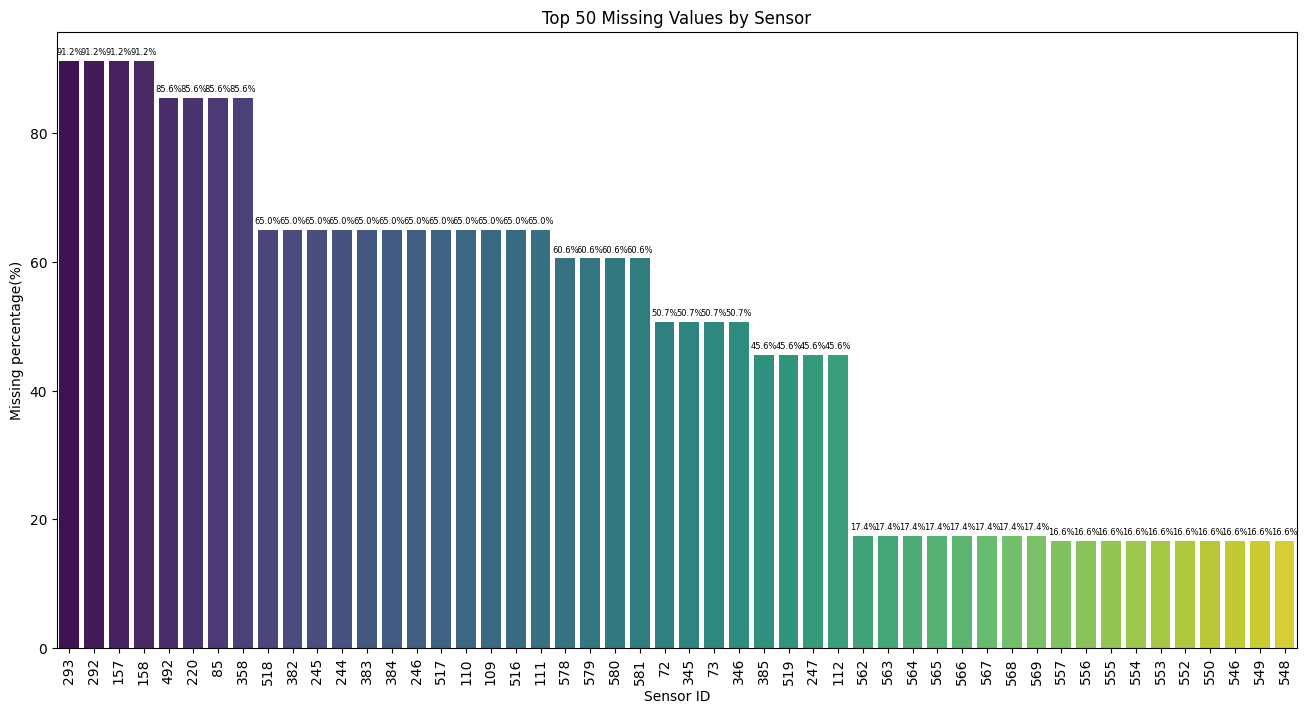

In [3]:
# 그래프 그리기(결측치 비율 top50 columns를 bar plot으로 시각화)

# secom dataset의 결측치의 비율을 "null_counts" Series로 저장
null_percent = my_data.isnull().mean()*100
# 상위 50개의 데이터만 추출
null_top50 = null_percent.sort_values(ascending=False).head(50)

plt.figure(figsize=(16,8))

# 막대그래프 작성
ax = sns.barplot(x=null_top50.index, y=null_top50.values, palette='viridis')

# 각 막대의 위에 값 레이블 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=6)
"""
ax.containers: 막대그래프 지칭
fmt='%.1f%%': "%.1f"(소수점 첫째까지 표시), "%%"(뒤에 % 붙임)
padding: 그래프와 간격 띄우기
"""

plt.title("Top 50 Missing Values by Sensor")
plt.xlabel("Sensor ID")
plt.ylabel("Missing percentage(%)")
# x축 눈금의 값을 반시계 방향으로 90도 회전
plt.xticks(rotation=90)

plt.show()

In [4]:
# constant columns 제거
n_unique = my_data.nunique()
constant_cols = n_unique[n_unique <= 1].index

print(f"상수 열의 개수: {len(constant_cols)}")
print(f"상수 열 목록: {constant_cols.tolist()}")
""".tolist(): 판다스나 넘파이의 인덱스나 시리즈 객체를 파이썬 기본 리스트 형태로 변환"""

my_data_dropped1 = my_data.drop(columns=constant_cols)

print(f"제거된 상수 열 개수: {len(constant_cols)}")
print(f"원본 열 개수: {my_data.shape[1]}")
print(f"제거 후 열 개수: {my_data_dropped1.shape[1]}")

""".shape[?}: 0 -> 행이 개수, 1 -> 열의 개수"""

상수 열의 개수: 116
상수 열 목록: ['5', '13', '42', '49', '52', '69', '97', '141', '149', '178', '179', '186', '189', '190', '191', '192', '193', '194', '226', '229', '230', '231', '232', '233', '234', '235', '236', '237', '240', '241', '242', '243', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '276', '284', '313', '314', '315', '322', '325', '326', '327', '328', '329', '330', '364', '369', '370', '371', '372', '373', '374', '375', '378', '379', '380', '381', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '414', '422', '449', '450', '451', '458', '461', '462', '463', '464', '465', '466', '481', '498', '501', '502', '503', '504', '505', '506', '507', '508', '509', '512', '513', '514', '515', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538']
제거된 상수 열 개수: 116
원본 열 개수: 592
제거 후 열 개수: 476


'.shape[?}: 0 -> 행이 개수, 1 -> 열의 개수'

In [5]:
# 결측 여부와 불량률 간의 연관성 확인

# 불량률 평균을 구하기 위해 불량=1, 정상=0인 시리즈 생성
labels = (my_data['Pass/Fail'] == 1).astype(int)

# 결측치가 존재하는 열만 추출
null_cols = my_data_dropped1.columns[my_data_dropped1.isnull().any()]

# 각 열에서 결측 여부와 불량률 관계 분석
results = []

# 결측일때의 불량률과, 정상일때의 불량률 비교
for col in null_cols:
    # my_data_dropped1 중 결측치를 가지는 열의 각 행들을 1(결측), 0(정상)으로 나타내는 시리즈
    is_null = my_data_dropped1[col].isnull().astype(int)
    # is_null이 1(결측)인 행번호의 labels 값들의 평균을 반환
    fail_when_null = labels[is_null == 1].mean()
    # is_null이 0(정상)인 행번호의 labels 값들의 평균을 반환
    fail_when_not_null = labels[is_null == 0].mean()
    results.append({
        'column': col,
        'null_ratio': is_null.mean(),
        'fail_rate_when_null': fail_when_null,
        'fail_rate_when_not_null': fail_when_not_null,
        'diff': abs(fail_when_null - fail_when_not_null)
    })

result_df = pd.DataFrame(results).sort_values('diff', ascending=False)
print(result_df.head(20))

# diff가 상위인 행의 결츨비율 매우 작음 -> 결측 비율이 0.05 이상인 열들에 대해서 비교
meaningful = result_df[result_df['null_ratio'] >= 0.05].sort_values('diff', ascending=False)
print(f"해당 열 개수: {len(meaningful)}")
print(meaningful.head(20))

    column  null_ratio  fail_rate_when_null  fail_rate_when_not_null      diff
28      31    0.001276                  0.5                 0.065815  0.434185
24      27    0.001276                  0.5                 0.065815  0.434185
27      30    0.001276                  0.5                 0.065815  0.434185
26      29    0.001276                  0.5                 0.065815  0.434185
25      28    0.001276                  0.5                 0.065815  0.434185
22      25    0.001276                  0.5                 0.065815  0.434185
23      26    0.001276                  0.5                 0.065815  0.434185
21      24    0.001276                  0.5                 0.065815  0.434185
20      23    0.001276                  0.5                 0.065815  0.434185
321    435    0.001276                  0.5                 0.065815  0.434185
19      22    0.001276                  0.5                 0.065815  0.434185
18      21    0.001276                  0.5         

In [6]:
# 확인 결과, 유의미한 비율의 결측치를 갖는 열에서, diff가 매우 작게 나타나는 것을 볼때, 결측 유무가 불량과 거의 관계 없음을 알 수 있다.
# -> 45.6% 이상의 결측 비율을 갖는 열은 제거(45.6%에서 불연속 변곡 발생)
# -> 그 이하의 열은 대체: 중앙값을 대체하여, 데이터 왜곡(중앙값 스파이크, 가짜 상봉형)이 심하게 발생하는 문제가 있었으므로, 스케일링 후 KNN Imputer로 대체

In [7]:
# 오류 방지를 위해 결측칙 있는지 우선 확인
print(my_data_dropped1['Time'].isnull().sum())

0


In [8]:
# 결측치가 없으므로 숫자로 변환
my_data_dropped1['Time'] = my_data_dropped1['Time'].astype('int64')

In [9]:
# 이상치 가공 전, 이상치 diff 분석 / 이상치 자체가 불량 신호인지 확인하기 위함
outlier_results = []

for col in my_data_dropped1.select_dtypes(include='number').columns:
    Q1 = my_data_dropped1[col].quantile(0.25)
    Q3 = my_data_dropped1[col].quantile(0.75)
    IQR = Q3 - Q1
    is_outlier = ((my_data_dropped1[col] < Q1 - 1.5*IQR) | 
                  (my_data_dropped1[col] > Q3 + 1.5*IQR)).astype(int)
    
    fail_when_outlier = labels[is_outlier == 1].mean()
    fail_when_normal = labels[is_outlier == 0].mean()
    
    outlier_results.append({
        'column': col,
        'outlier_ratio': is_outlier.mean(),
        'fail_when_outlier': fail_when_outlier,
        'fail_when_normal': fail_when_normal,
        'diff': abs(fail_when_outlier - fail_when_normal)
    })

outlier_result_df = pd.DataFrame(outlier_results).sort_values('diff', ascending=False)
print(outlier_result_df.head(20))

        column  outlier_ratio  fail_when_outlier  fail_when_normal      diff
475  Pass/Fail       0.066369           1.000000          0.000000  1.000000
51          55       0.003191           0.400000          0.065301  0.334699
446        561       0.005743           0.333333          0.064827  0.268507
60          64       0.042119           0.287879          0.056629  0.231250
204        221       0.004467           0.285714          0.065385  0.220330
403        493       0.004467           0.285714          0.065385  0.220330
26          27       0.015316           0.250000          0.063513  0.186487
444        559       0.007658           0.250000          0.064952  0.185048
177        188       0.002553           0.250000          0.065899  0.184101
73          78       0.010849           0.235294          0.064516  0.170778
435        550       0.008296           0.230769          0.064994  0.165776
20          21       0.022974           0.222222          0.062704  0.159518

In [10]:
# Pass/Fail 열은 무시, diff의 최대가 0.33으로 꽤 연관성 있음.

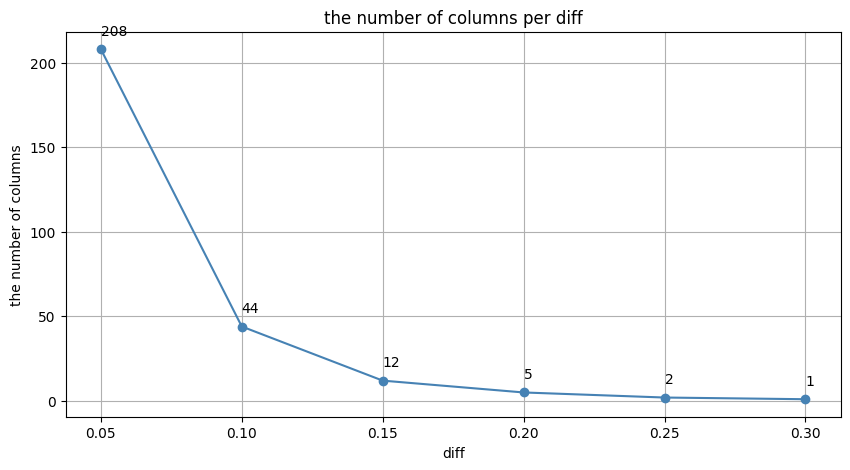

In [11]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
counts = [208, 44, 12, 5, 2, 1]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, counts, marker='o', color='steelblue')
plt.title("the number of columns per diff")
plt.xlabel("diff")
plt.ylabel("the number of columns")
for t, c in zip(thresholds, counts):
    plt.annotate(f'{c}', (t, c), textcoords="offset points", xytext=(0, 10))
plt.grid(True)
plt.show()

In [12]:
# 0.05와 0.10 사이에 더 자세한 추세 호가인 필요

diff 0.05 이상: 208개 열
diff 0.06 이상: 179개 열
diff 0.07 이상: 79개 열
diff 0.08 이상: 61개 열
diff 0.09 이상: 53개 열
diff 0.1 이상: 44개 열


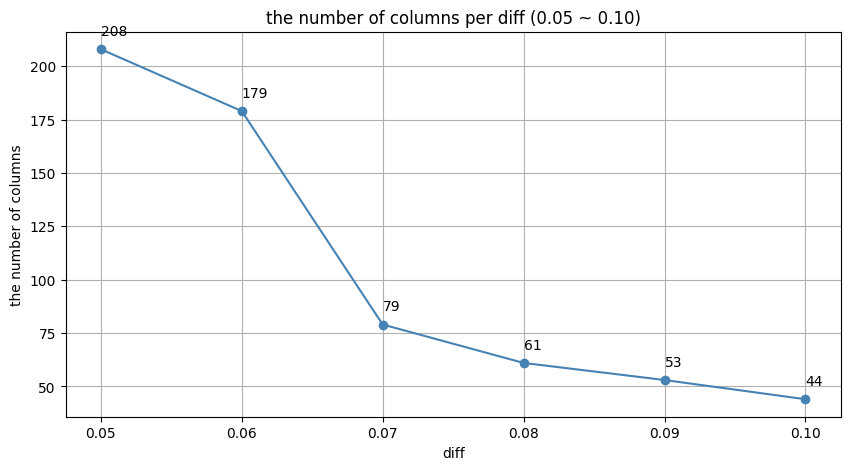

In [13]:
import numpy as np

thresholds_detail = [0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
counts_detail = []

for t in thresholds_detail:
    count = len(outlier_result_df[
        (outlier_result_df['diff'] >= t) & 
        (outlier_result_df['column'] != 'Pass/Fail')
    ])
    counts_detail.append(count)
    print(f"diff {t} 이상: {count}개 열")

plt.figure(figsize=(10, 5))
plt.plot(thresholds_detail, counts_detail, marker='o', color='steelblue')
plt.title("the number of columns per diff (0.05 ~ 0.10)")
plt.xlabel("diff")
plt.ylabel("the number of columns")
for t, c in zip(thresholds_detail, counts_detail):
    plt.annotate(f'{c}', (t, c), textcoords="offset points", xytext=(0, 10))
plt.grid(True)
plt.show()

In [14]:
# 0.07은 elbow지점 -> 자연스러운 경계

In [15]:
# Flagging 대상 열 (0.07 기준 + 40, 129 수동 추가)
flagging_cols = outlier_result_df[
    (outlier_result_df['diff'] >= 0.07) & 
    (outlier_result_df['column'] != 'Pass/Fail')
]['column'].tolist()

flagging_cols += ['40', '129']
print(f"Flagging 대상 열 개수: {len(flagging_cols)}")

# Flagging 수행
before_cols = my_data_dropped1.shape[1]

for col in flagging_cols:
    Q1 = my_data_dropped1[col].quantile(0.25)
    Q3 = my_data_dropped1[col].quantile(0.75)
    IQR = Q3 - Q1
    my_data_dropped1[f'{col}_outlier_flag'] = (
        (my_data_dropped1[col] < Q1 - 1.5*IQR) |
        (my_data_dropped1[col] > Q3 + 1.5*IQR)
    ).astype(int)

print(f"Flagging 전 열 개수: {before_cols}")
print(f"Flagging 후 열 개수: {my_data_dropped1.shape[1]}")
print(f"추가된 열 개수: {my_data_dropped1.shape[1] - before_cols}")

Flagging 대상 열 개수: 81
Flagging 전 열 개수: 476
Flagging 후 열 개수: 557
추가된 열 개수: 81


In [16]:
# 데이터에 이상치가 있으므로, 이상치에 영향을 덜 받는 IQR 기반 RobustScaler 사용

In [17]:
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

# 45.6% 이상 결측 열 제거
cols_to_drop = null_percent[null_percent >= 45.6].index
my_data_dropped2 = my_data_dropped1.drop(columns=cols_to_drop)
print(f"제거된 열 개수: {len(cols_to_drop)}")
print(f"제거 후 열 개수: {my_data_dropped2.shape[1]}")

# RobustScaler 적용
scaler = RobustScaler()
data_scaled = scaler.fit_transform(my_data_dropped2)

# KNN Imputer 적용
imputer = KNNImputer(n_neighbors=5)
data_imputed_scaled = imputer.fit_transform(data_scaled)

# 원래 범위 복원
final_data = pd.DataFrame(
    scaler.inverse_transform(data_imputed_scaled),
    columns=my_data_dropped2.columns
)

print(f"결측치 수: {final_data.isnull().sum().sum()}")

제거된 열 개수: 32
제거 후 열 개수: 525
결측치 수: 0


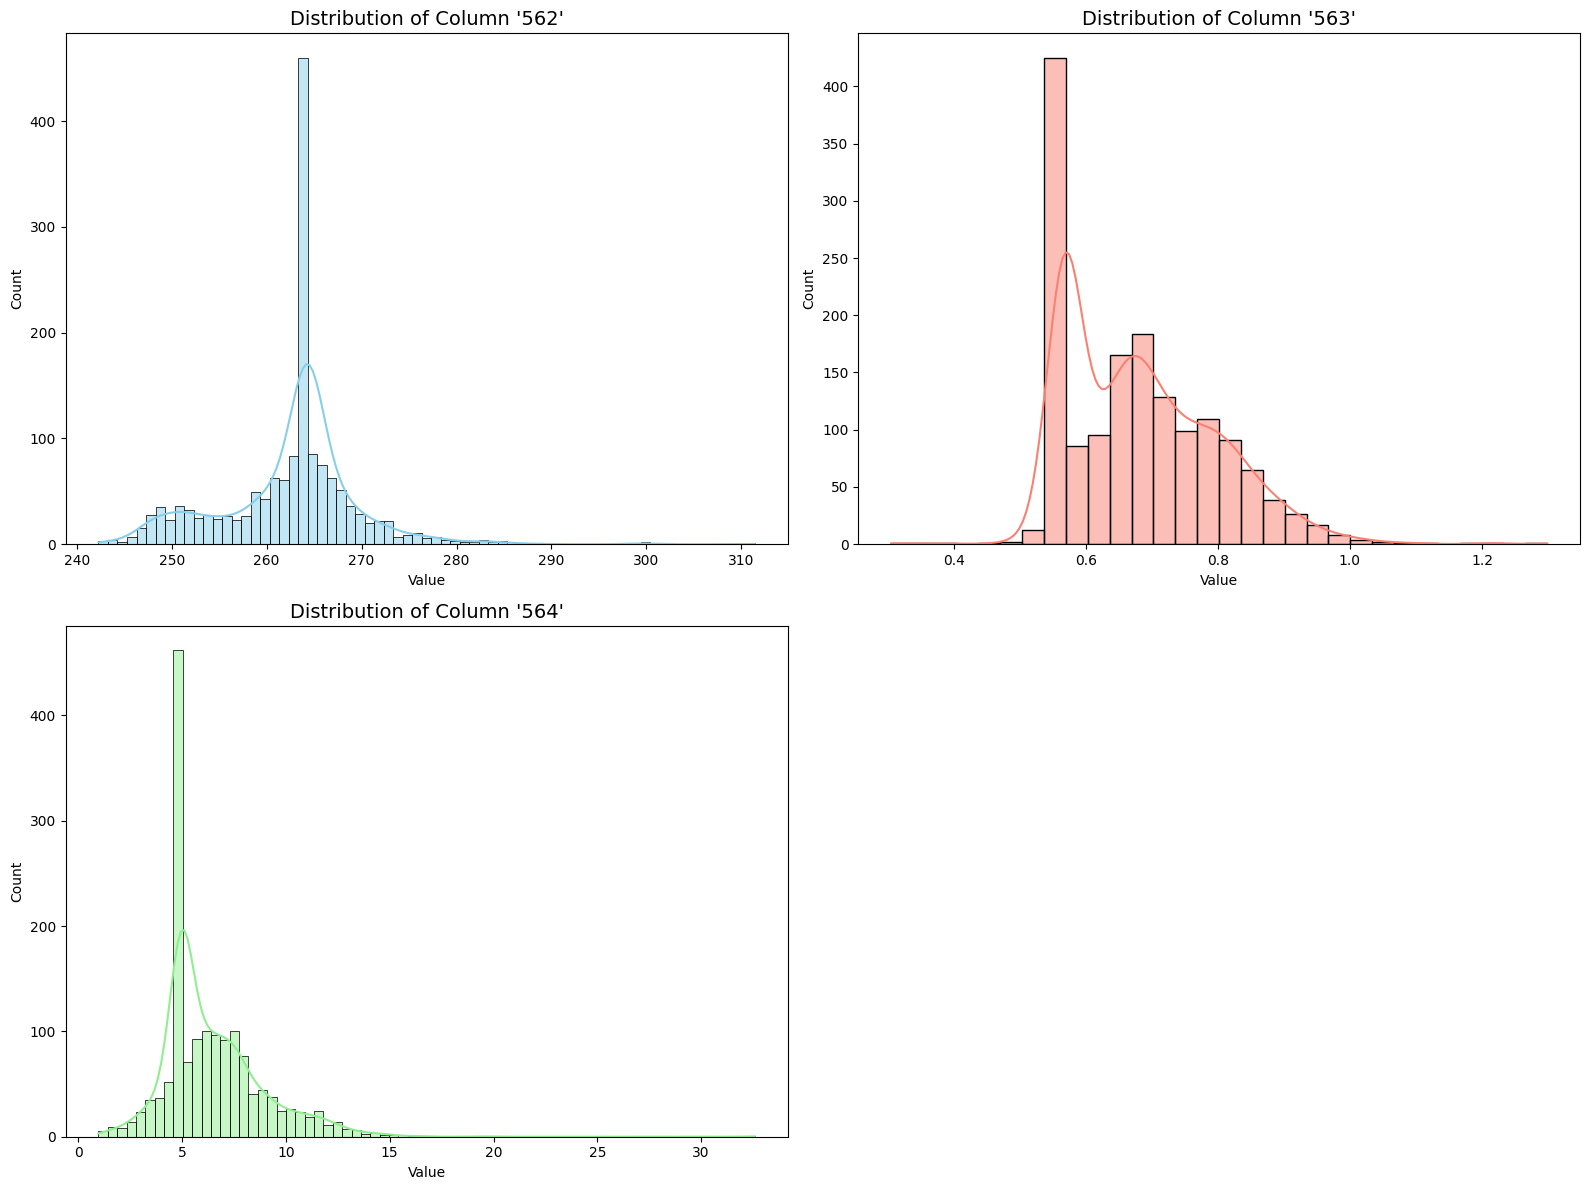

In [18]:
# 중앙값 처리 방식에서 문제를 보였던, 562, 563, 564 열 재확인
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
"""
fig: plot ouput 전체를 관리하는 객체
axes: 각각의 칸들을 답고 있는 리스트
plt.subplot(a, b): a -> 행 개수, b -> 열 개수  
"""
sns.histplot(final_data['562'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title("Distribution of Column '562'", fontsize=14)
axes[0, 0].set_xlabel("Value")

sns.histplot(final_data['563'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title("Distribution of Column '563'", fontsize=14)
axes[0, 1].set_xlabel("Value")

sns.histplot(final_data['564'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title("Distribution of Column '564'", fontsize=14)
axes[1, 0].set_xlabel("Value")

# 마지막 칸[1,1] 숨기기
axes[1, 1].axis('off')

# 그래프 간 간격 자동 조절
plt.tight_layout()
plt.show()

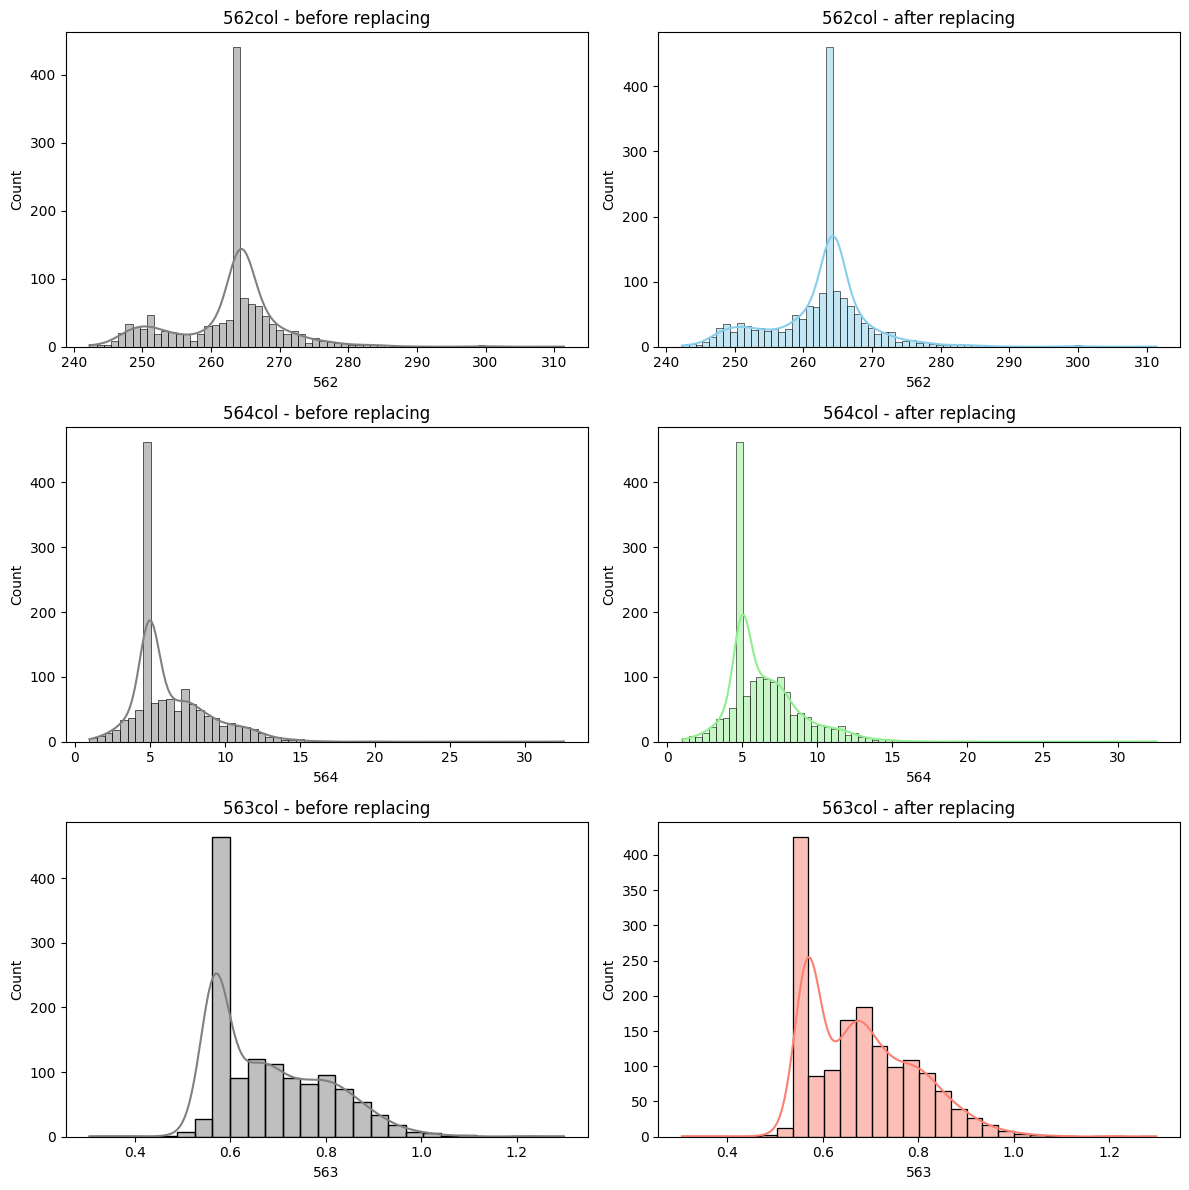

In [19]:
# 그래프의 형태의 원인이 대체인지 원본데이터 자체의 특성인지 확인 필요
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# 562 대체 전(결측치 제외)
sns.histplot(my_data_dropped2['562'], kde=True, ax=axes[0,0], color='gray')
axes[0,0].set_title("562col - before replacing")
# 562 대체 후
sns.histplot(final_data['562'], kde=True, ax=axes[0,1], color='skyblue')
axes[0,1].set_title("562col - after replacing")

# 564 대체 전(결측치 제외)
sns.histplot(my_data_dropped2['564'], kde=True, ax=axes[1,0], color='gray')
axes[1,0].set_title("564col - before replacing")
# 564 대체 후
sns.histplot(final_data['564'], kde=True, ax=axes[1,1], color='lightgreen')
axes[1,1].set_title("564col - after replacing")

# 563 대체 전(결측치 제외)
sns.histplot(my_data_dropped2['563'], kde=True, ax=axes[2,0], color='gray')
axes[2,0].set_title("563col - before replacing")
# 563 대체 후
sns.histplot(final_data['563'], kde=True, ax=axes[2,1], color='salmon')
axes[2,1].set_title("563col - after replacing")

plt.tight_layout()
plt.show()

In [20]:
# 562, 564의 중앙값 스파이크는 원본 그래프 자체의 성질임 -> 대체가 잘 이뤄짐.
# 563은 현재 약한 가짜 쌍봉형 생성 -> 중앙값 대체보다 훨씬 약하며, 17.4% 대체를 고려할때 불가피하다고 판단.
# 즉, 현재 대체 선택지 중 KNN이 가장 나은 방식으로 고려.

In [21]:
# 각 열의 이상치 비율 확인 (IQR 방식, 급격하게 변하는 이상치의 영향을 피하기 위함)
outlier_ratio = {}

for col in final_data.columns:
    if col == 'Time' or 'outlier_flag' in col:
        continue
    Q1 = final_data[col].quantile(0.25)
    Q3 = final_data[col].quantile(0.75)
    IQR = Q3 - Q1
    range_lower = Q1 - 1.5 * IQR
    range_upper = Q3 + 1.5 * IQR
    outlier_ratio[col] = ((final_data[col] < range_lower) | (final_data[col] > range_upper)).mean() * 100

outlier_df = pd.Series(outlier_ratio).sort_values(ascending=False)
print(outlier_df.head(20))

31     22.654754
40     20.931717
544    15.252074
129    15.188258
312    14.932993
195    14.932993
177    14.677728
448    14.677728
467    13.975750
251    12.827058
59     12.699426
523    12.699426
23     12.444161
41     12.444161
116    12.252712
389    12.061264
562    11.933631
545    11.805999
335    11.550734
471    11.486918
dtype: float64


In [22]:
# 이상치가 꽤 높게 나타나는 것을 확인
# Time 열은 단순 시간 데이터로, 이상치 비율은 높게 나타나지만 무시해도 무관.
# 이상치와 불량률이 실제로 상관관계를 가지는지 확인 필요

/tmp/ipykernel_17/2727369150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=final_data[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/2727369150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=final_data[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/2727369150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=final_data[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/2727369150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be 

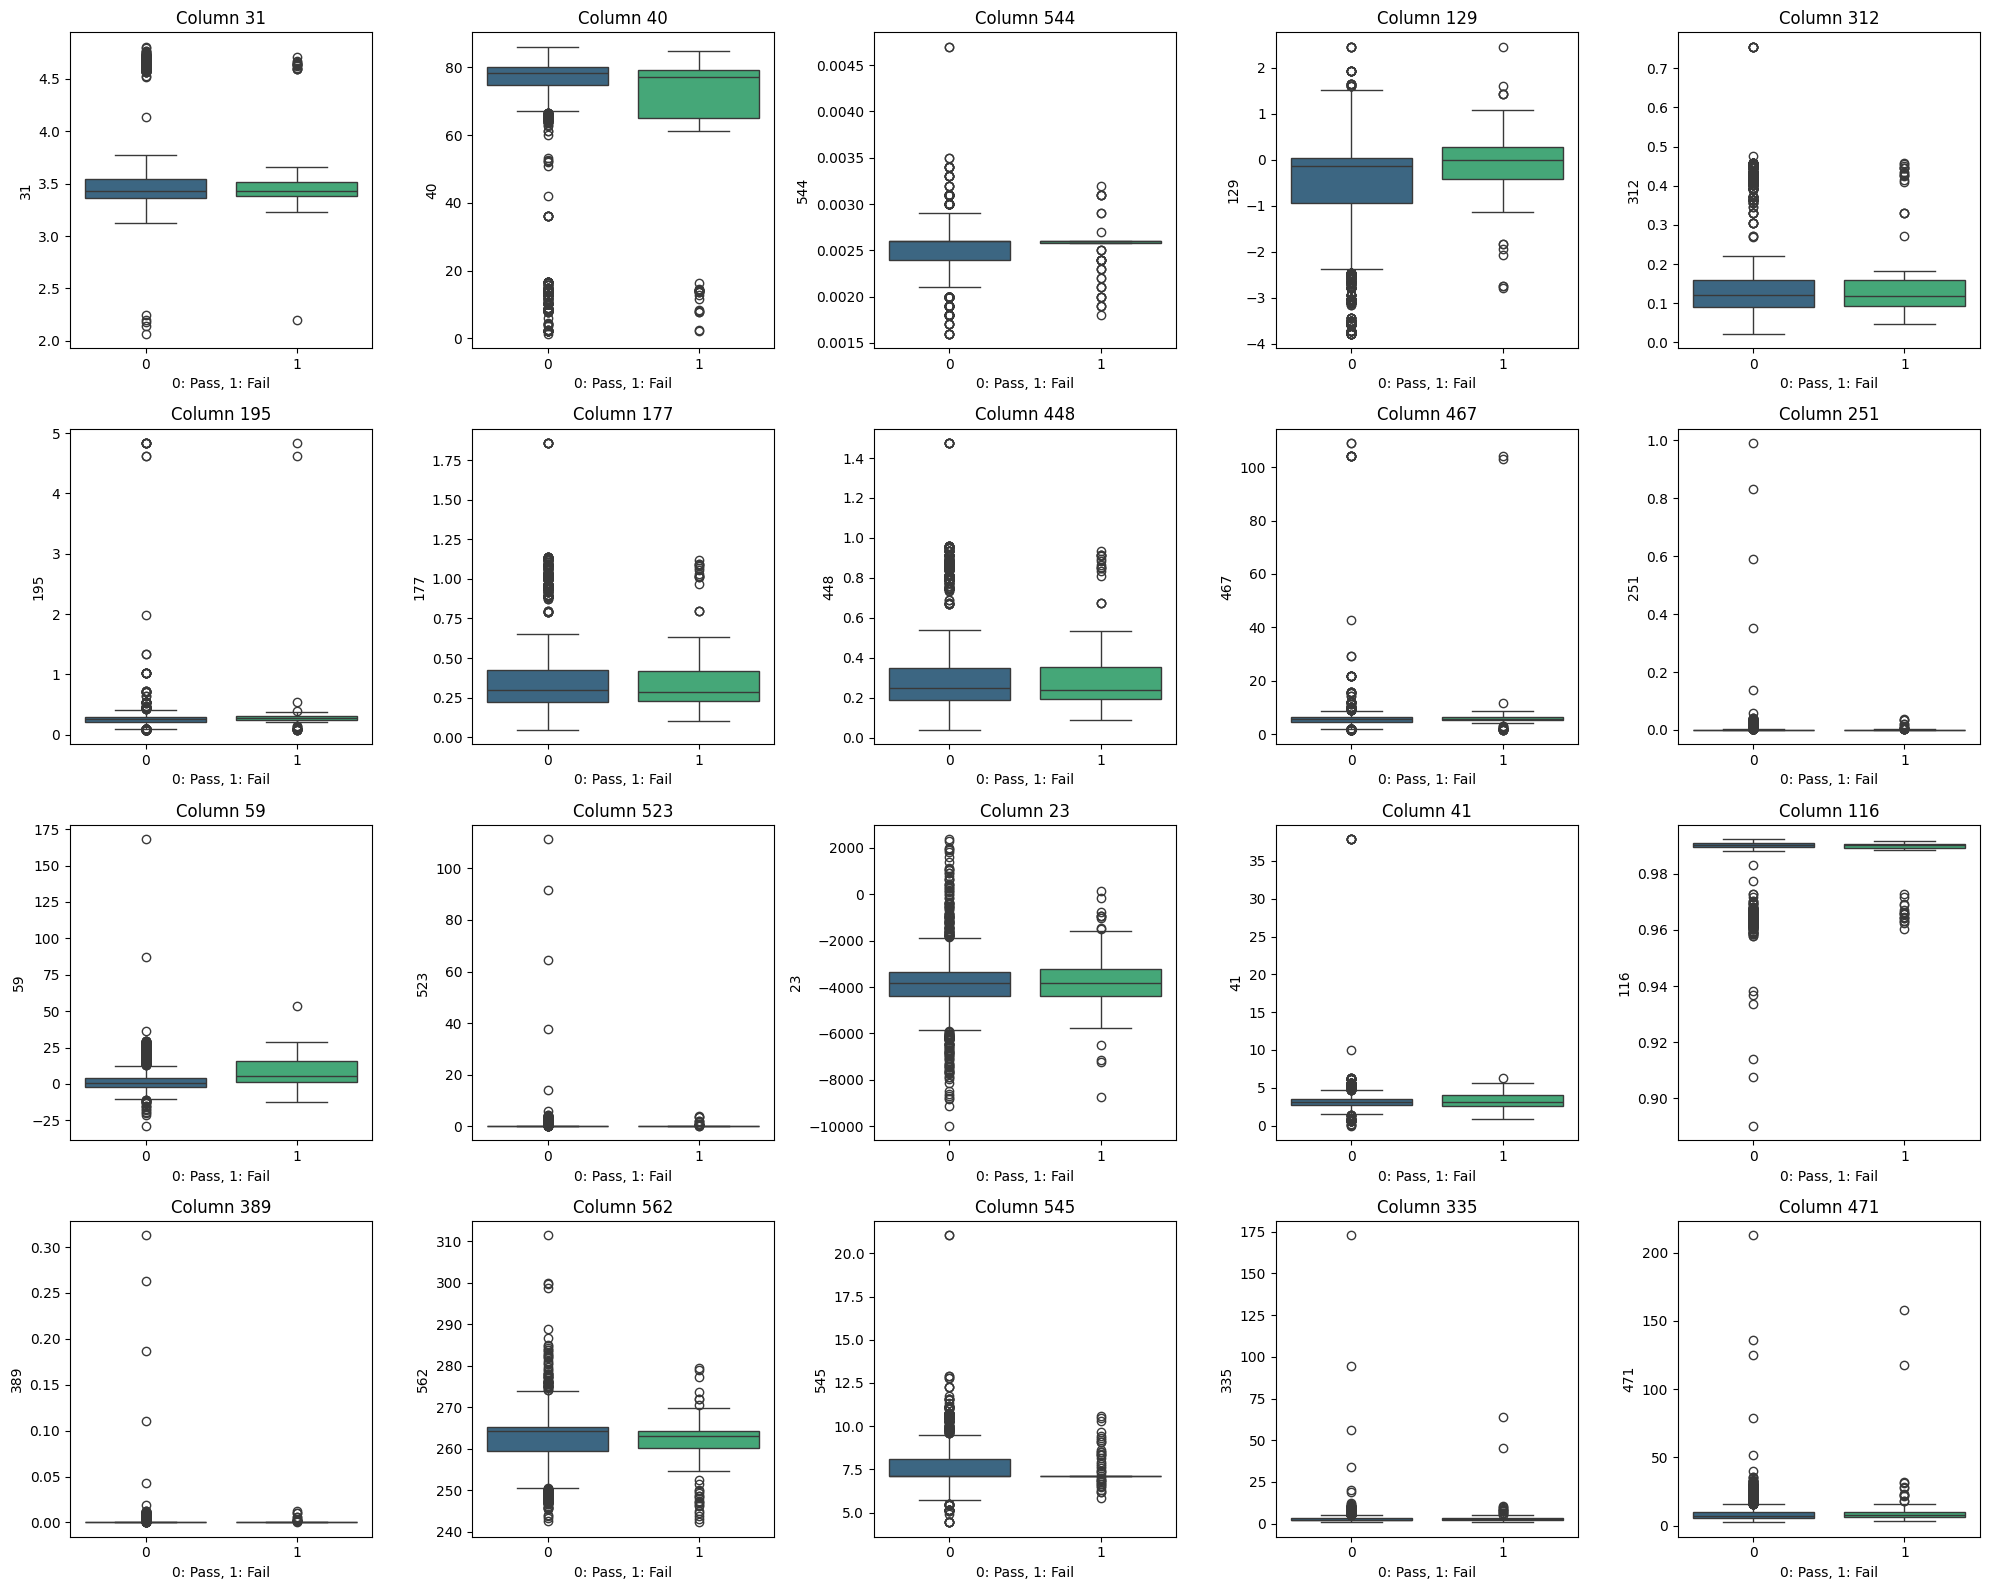

In [23]:
# 이상치 비율 상위 20개 열 확인
top_outlier_cols = outlier_df.head(20).index.tolist()
"""tolist() -> 시리즈를 기본 리스트로 변환"""

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()
"""flatten() -> 2차원 배열을 1차원으로 합침"""

for i, col in enumerate(top_outlier_cols):
    sns.boxplot(x=labels, y=final_data[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f"Column {col}")
    axes[i].set_xlabel("0: Pass, 1: Fail")
"""enumerate() -> 반복문에서 인덱스와 값을 동시에 꺼내 사용 가능"""

plt.tight_layout()
plt.show()

In [24]:
print(flagging_cols)
print(outlier_result_df[outlier_result_df['column'].isin(['40', '129'])])

['55', '561', '64', '221', '493', '27', '559', '188', '78', '550', '21', '298', '65', '556', '26', '25', '38', '341', '148', '66', '324', '311', '477', '434', '63', '291', '343', '359', '510', '62', '205', '103', '59', '348', '437', '22', '165', '160', '299', '295', '553', '421', '7', '154', '346', '100', '584', '479', '345', '571', '300', '429', '156', '388', '427', '83', '76', '385', '431', '79', '163', '16', '77', '521', '331', '472', '361', '89', '252', '353', '317', '120', '249', '114', '387', '336', '213', '519', '247', '40', '129']
    column  outlier_ratio  fail_when_outlier  fail_when_normal      diff
123    129       0.151883           0.021008          0.074492  0.053484
39      40       0.210593           0.103030          0.056589  0.046442


In [25]:
# 0.10 기준에 40, 129열들은 Flagging이 안 됨.
# 기준을 0.05로 낮추기에는 208개로 너무 많음
# 확인 결과 Flagging 기준 0.07로 낮춤 / 여전히 Flagging 안 되긴 함
# 40, 129열처럼 이상치가 많아 differ이 희석 됐을 가능성이 있는 다른 열도 조사 필요(수동 추가)

In [26]:
# 이상치 비율이 높으면서 박스플롯에서 차이가 보이는 열 확인
# 이상치 비율 10% 이상인 열 전체를 박스플롯으로 확인
high_outlier_cols = outlier_result_df[
    (outlier_result_df['outlier_ratio'] >= 0.10) &
    (outlier_result_df['column'] != 'Pass/Fail')
]['column'].tolist()

print(f"이상치 비율 10% 이상 열 개수: {len(high_outlier_cols)}")

이상치 비율 10% 이상 열 개수: 24


/tmp/ipykernel_17/3426865962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=my_data_dropped1[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/3426865962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=my_data_dropped1[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/3426865962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=my_data_dropped1[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/3426865962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

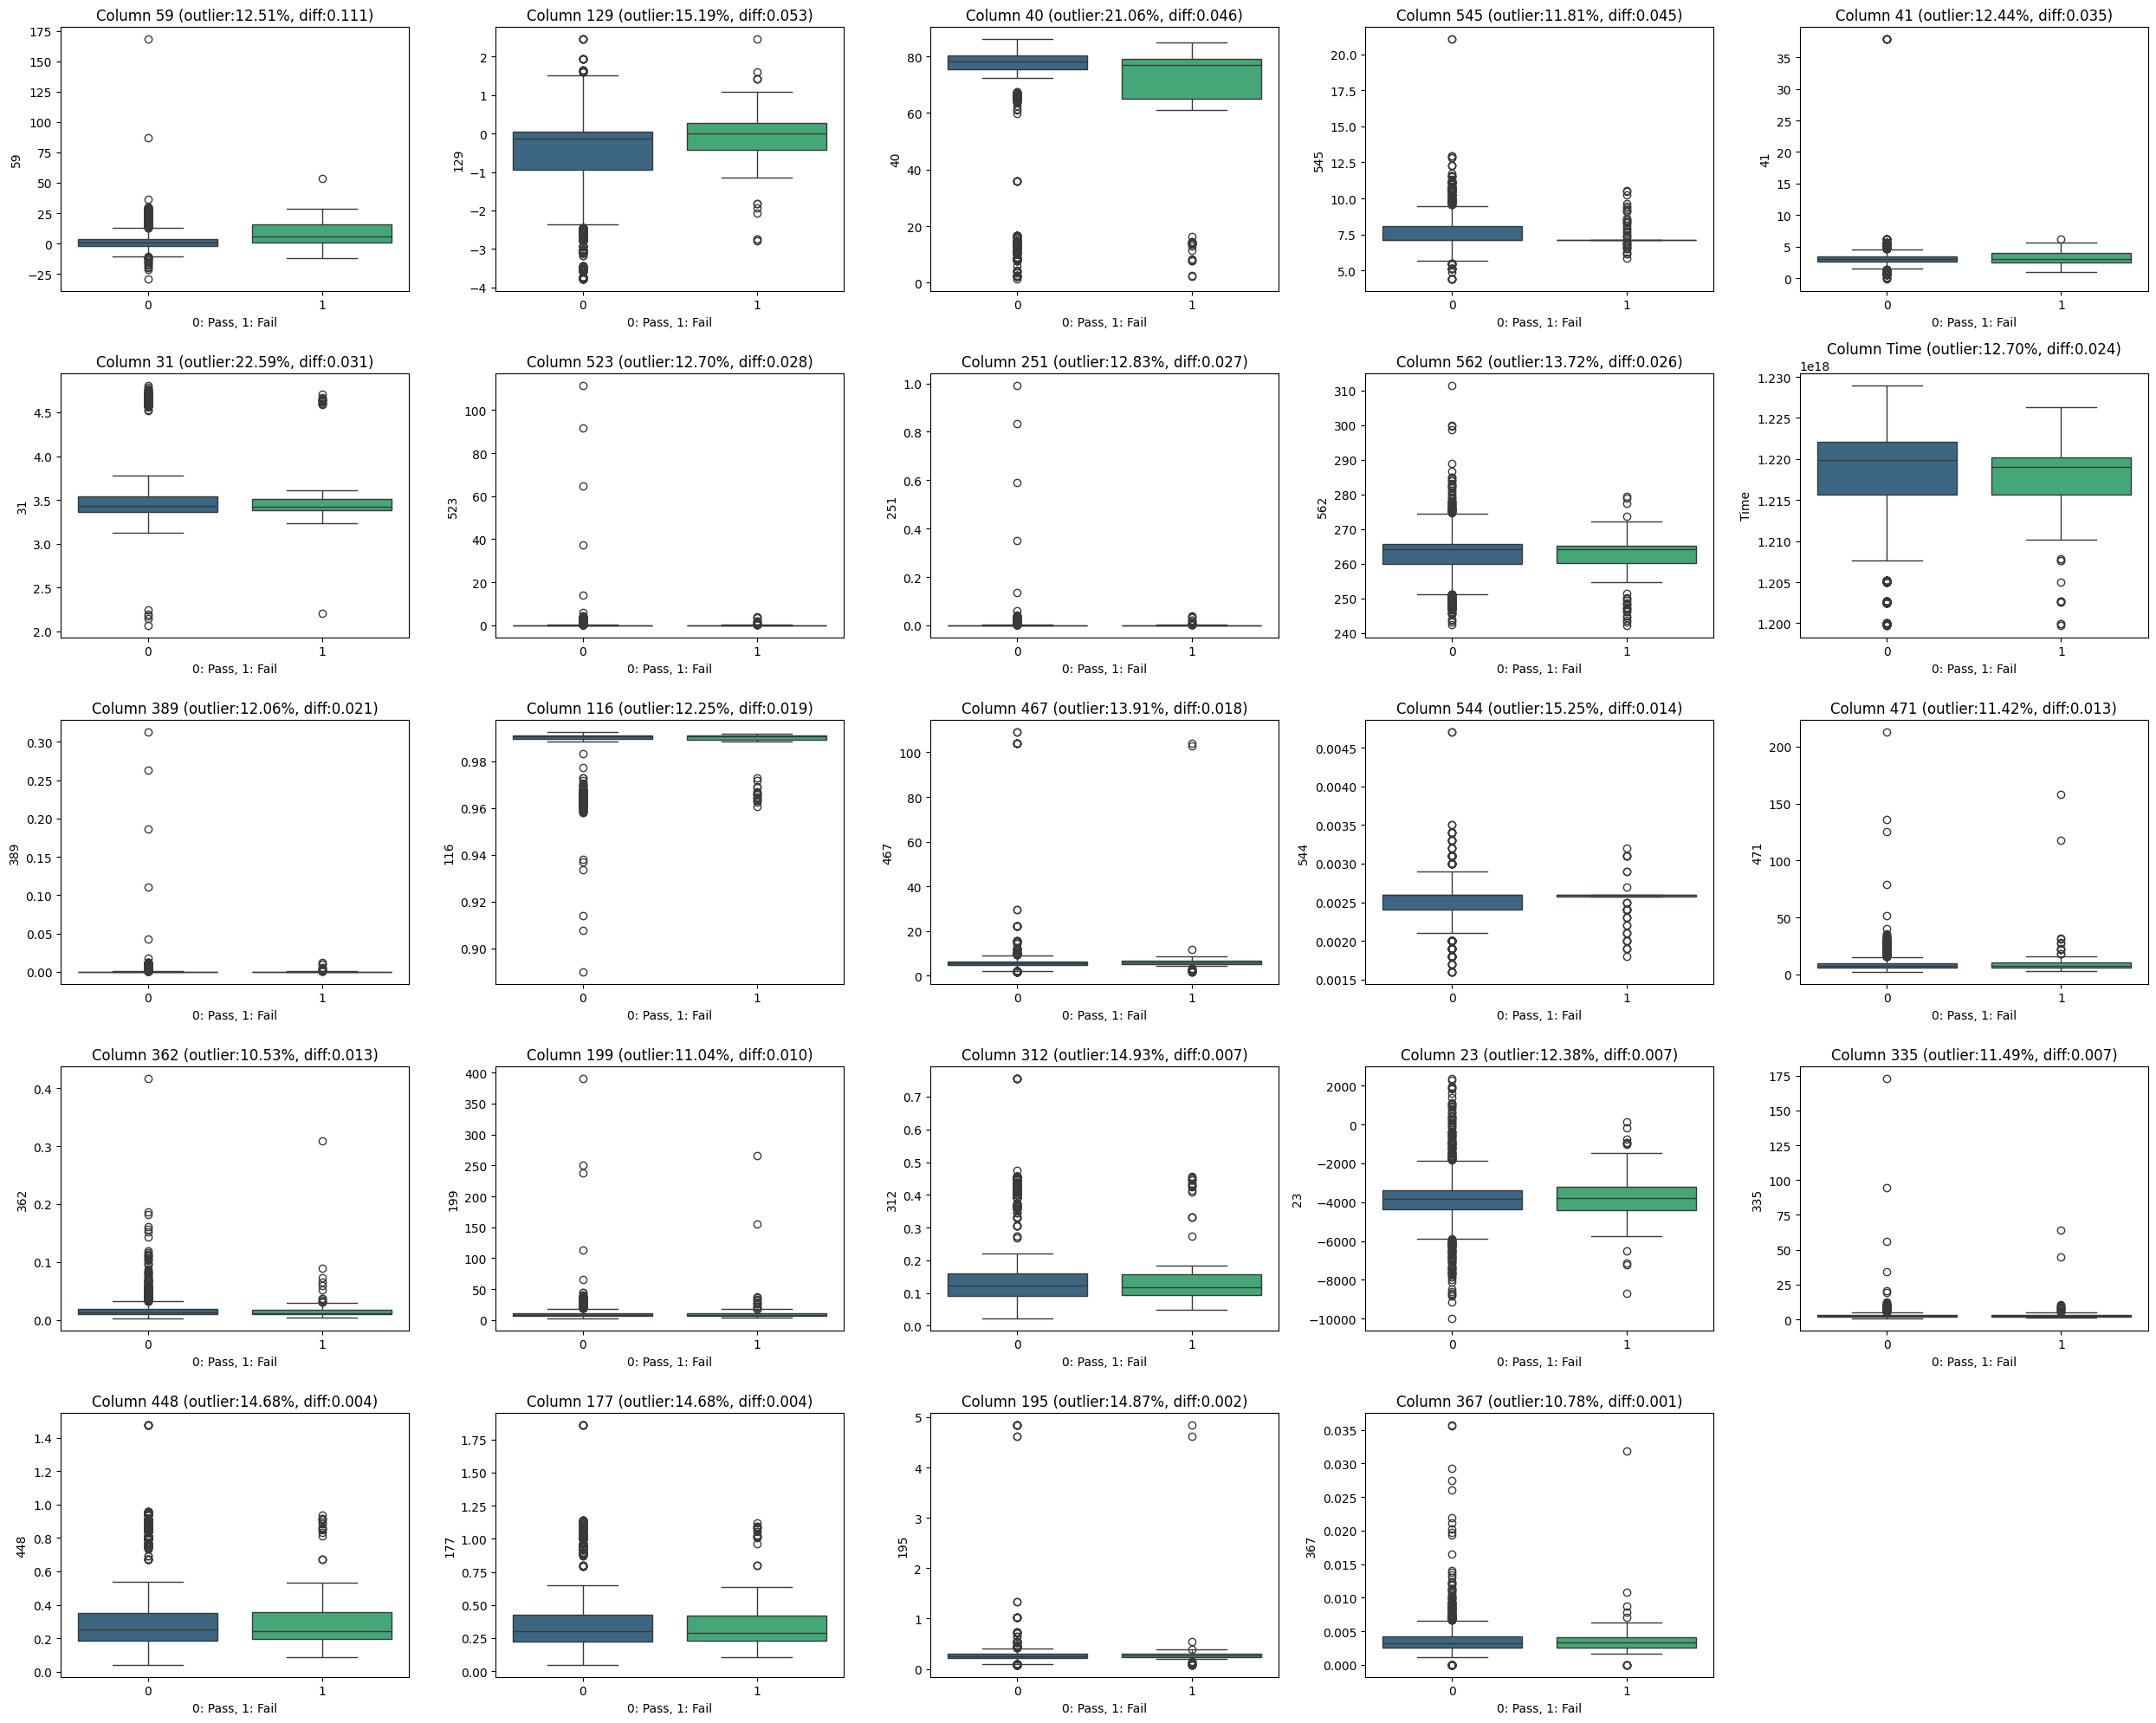

In [27]:
fig, axes = plt.subplots(5, 5, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(high_outlier_cols):
    sns.boxplot(x=labels, y=my_data_dropped1[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f"Column {col} (outlier:{outlier_result_df[outlier_result_df['column']==col]['outlier_ratio'].values[0]:.2%}, diff:{outlier_result_df[outlier_result_df['column']==col]['diff'].values[0]:.3f})")
    axes[i].set_xlabel("0: Pass, 1: Fail")

# 남은 칸 숨기기
for i in range(len(high_outlier_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [28]:
# 확인 결과, 59, 129, 40, Time 열이 시각적 차이 있음
# Time은 무시, 59열은 이미 Flagging 됨
# 129, 40 열 수동으로 추가

In [29]:
# 99셀에 flagging_cols += ['40', '129'] 추가
# Flagging 코드 수정 완료

In [30]:
# 현재, 불량 데이터 샘플 비율이 매우 적어, 제거 어려움.
# 클리핑 방식 사용 -> 이상치를 IQR 방식의 상한값 or 하한값으로 대체
# -> Flagging으로 정보 보존 했으므로, 클리핑 방식이 적절

In [31]:
# 각 열에 클리핑 방식 적용
data_clipped = final_data.copy()

for col in data_clipped.columns:
    # Pass/Fail과 flag 열은 클리핑 제외
    if col == 'Pass/Fail' or 'outlier_flag' in col:
        continue
    Q1 = data_clipped[col].quantile(0.25)
    Q3 = data_clipped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data_clipped[col] = data_clipped[col].clip(lower, upper)
    """clip(하한, 상한) -> 하한보다 작은 값은 하한값으로, 상한보다 큰 값은 상한값으로 대체"""

# 클리핑 전후 이상치 수 비교
before = final_data.apply(
    lambda x: ((x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) | 
               (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))).sum()).sum()

print(f"클리핑 전 이상치 수: {before}")
print(f"클리핑 후 이상치 수: {data_clipped.apply(lambda x: ((x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) | 
                                                    (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))).sum()).sum()}")

클리핑 전 이상치 수: 27824
클리핑 후 이상치 수: 3936


In [32]:
# 이상치 대체 완료
# features 간 상관관계 확인 필요(중복 열 제거)

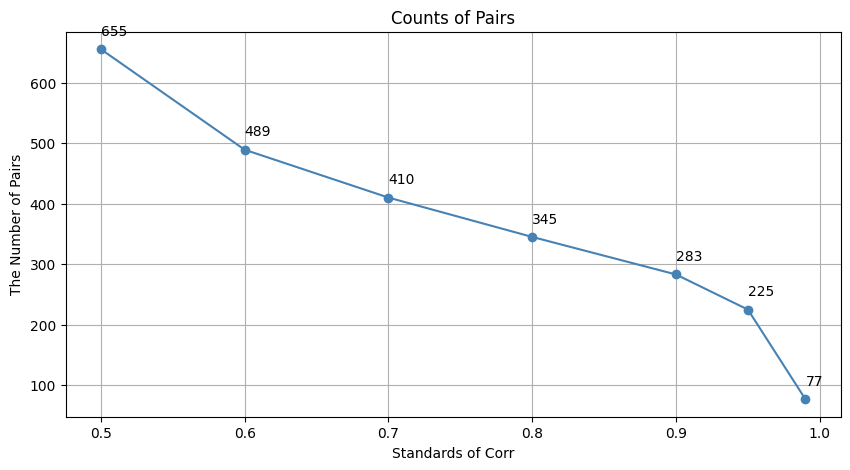

In [33]:
# 상관관계 행렬 계산
corr_matrix = data_clipped.corr()
"""corr(): 모든 열 간의 상관관계를 행렬로 저장"""

# 상관관계 구간별 쌍 개수 확인 / 기준 확립 위해 조사
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
counts = [655, 489, 410, 345, 283, 225, 77]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, counts, marker='o', color='steelblue')
plt.title("Counts of Pairs")
plt.xlabel("Standards of Corr")
plt.ylabel("The Number of Pairs")
for i, (t, c) in enumerate(zip(thresholds, counts)):
    plt.annotate(f'{c}', (t, c), textcoords="offset points", xytext=(0, 10))
plt.grid(True)
plt.show()

상관관계 0.95 이상: 234쌍
상관관계 0.96 이상: 193쌍
상관관계 0.97 이상: 160쌍
상관관계 0.98 이상: 131쌍
상관관계 0.99 이상: 84쌍


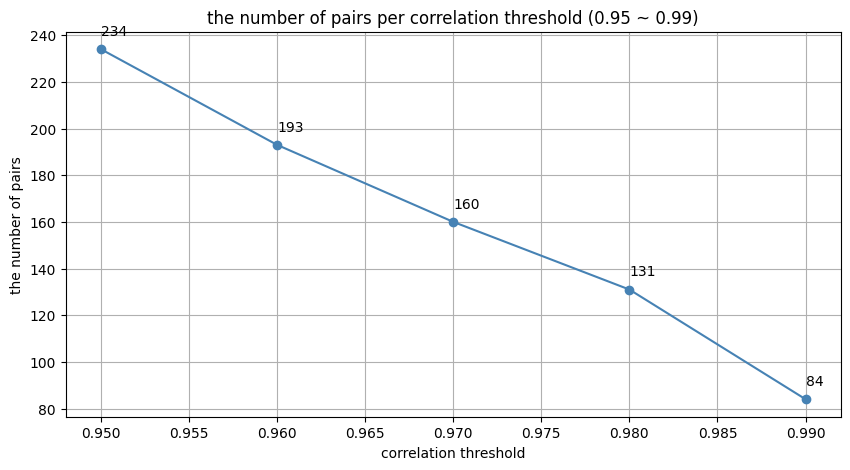

In [34]:
thresholds_detail = [0.95, 0.96, 0.97, 0.98, 0.99]
counts_detail = []

for t in thresholds_detail:
    count = 0
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= t:
                count += 1
    counts_detail.append(count)
    print(f"상관관계 {t} 이상: {count}쌍")

plt.figure(figsize=(10, 5))
plt.plot(thresholds_detail, counts_detail, marker='o', color='steelblue')
plt.title("the number of pairs per correlation threshold (0.95 ~ 0.99)")
plt.xlabel("correlation threshold")
plt.ylabel("the number of pairs")
for t, c in zip(thresholds_detail, counts_detail):
    plt.annotate(f'{c}', (t, c), textcoords="offset points", xytext=(0, 10))
plt.grid(True)
plt.show()

In [35]:
# 조사 결과, 0.95까지는 완만하게 감소하다가, 0.99에서 급격히 감소하는 elbow 확인
# 0.95에서 0.99사이에 elbow가 보이지 않음.
# 상관관계 중복 제거의 기준을 0.95하는 것이 합리적.

In [36]:
# 상관관계가 0.95 이상인 쌍 시각적 확인
high_corr_pairs = []

"""j를 i+1부터 시작하게 해, 중복되는 관계, 동인 열 간 관계 확인 안 함"""
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) >= 0.95:
            high_corr_pairs.append({
                'col1': corr_matrix.columns[i],
                'col2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
print(f"상관관계 0.95 이상 쌍 개수: {len(high_corr_df)}")
print(high_corr_df.head(20))

상관관계 0.95 이상 쌍 개수: 234
                 col1              col2  correlation
225  221_outlier_flag  493_outlier_flag     1.000000
231  249_outlier_flag  387_outlier_flag     1.000000
232  114_outlier_flag  387_outlier_flag     1.000000
233  519_outlier_flag  247_outlier_flag     1.000000
230  249_outlier_flag  114_outlier_flag     1.000000
227   26_outlier_flag   25_outlier_flag     1.000000
64                172               174     1.000000
174               307               309     0.999999
147               254               526     0.999977
35                153               426     0.999933
126               222               494     0.999930
23                147               420     0.999899
78                176               447     0.999887
40                155               428     0.999872
153               268               540     0.999837
137               248               520     0.999739
220               572               576     0.999718
42                156  

In [37]:
# 상관관계가 0.95이상인 쌍에서 col2만 제거 대상으로 하여 추출
cols_to_remove = set(high_corr_df['col2'].tolist())
print(f"제거할 열 개수: {len(cols_to_remove)}")

data_cleaned = data_clipped.drop(columns=cols_to_remove)
print(f"제거 전 열 개수: {data_clipped.shape[1]}")
print(f"제거 후 열 개수: {data_cleaned.shape[1]}")

# Pass/Fail 열 분리
# Pass/Fail은 label이지 피처가 아니기때문에 모델링 단계에서 입력 데이터(X)와 정답(y)을 분리해야 하므로 지금 제거
y = data_cleaned['Pass/Fail']
X = data_cleaned.drop(columns=['Pass/Fail'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

제거할 열 개수: 169
제거 전 열 개수: 525
제거 후 열 개수: 356
X shape: (1567, 355)
y shape: (1567,)


정상(-1): 1463개 (93.4%)
불량( 1): 104개 (6.6%)


/tmp/ipykernel_17/1696053030.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=my_data['Pass/Fail'], palette='viridis', ax=axes[0])


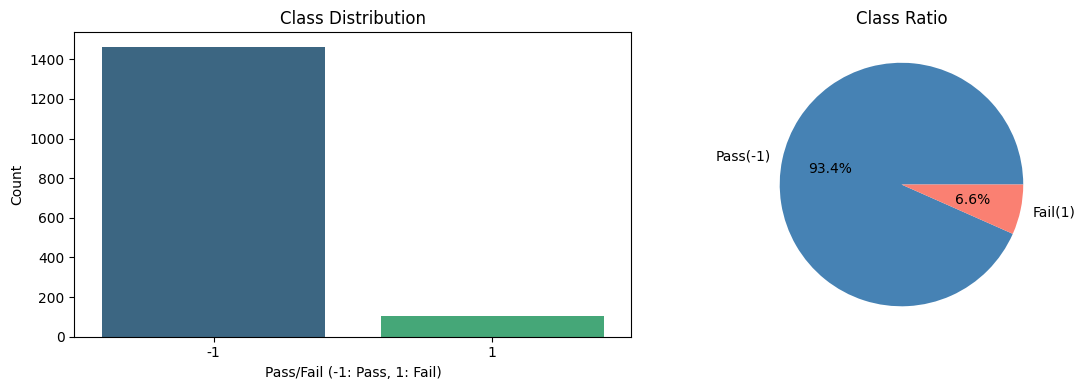

In [38]:
# 클래스 불균형 확인
class_counts = data_cleaned['Pass/Fail'].value_counts()
class_ratio = data_cleaned['Pass/Fail'].value_counts(normalize=True) * 100

print(f"정상(-1): {class_counts[-1]}개 ({class_ratio[-1]:.1f}%)")
print(f"불량( 1): {class_counts[1]}개 ({class_ratio[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=my_data['Pass/Fail'], palette='viridis', ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Pass/Fail (-1: Pass, 1: Fail)")
axes[0].set_ylabel("Count")

axes[1].pie(class_counts, labels=['Pass(-1)', 'Fail(1)'], autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title("Class Ratio")

plt.tight_layout()
plt.show()

In [39]:
# Pass/Fail과 features간 상관관계 파악 필요
# MI 사용이 가장 적합해 보임
# 비선형 관계 포착 가능 / 클래스 불균형에 강함

Pass/Fail과 MI 상위 20개 피처:
Time    0.031624
577     0.027124
128     0.024809
412     0.023211
41      0.022780
33      0.022739
570     0.021089
126     0.020969
573     0.020405
407     0.018925
56      0.018525
331     0.018403
121     0.018362
70      0.018223
273     0.018105
133     0.018068
571     0.017983
39      0.017784
57      0.017712
122     0.017691
dtype: float64


/tmp/ipykernel_17/4139663748.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_df.head(20).values, y=mi_df.head(20).index, palette='viridis')


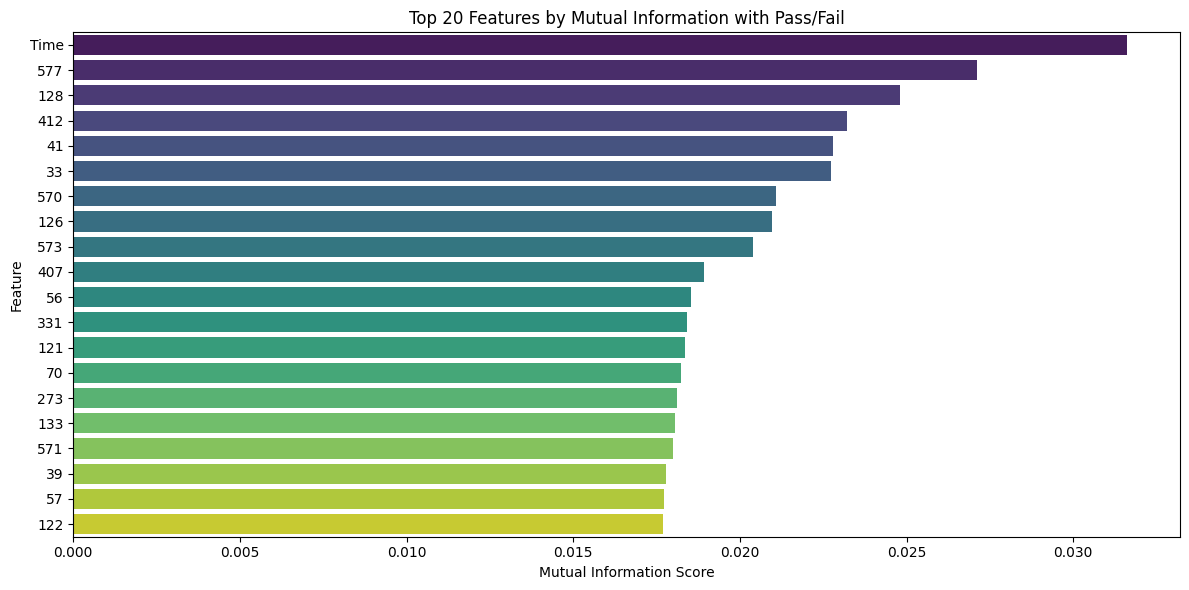

In [40]:
from sklearn.feature_selection import mutual_info_classif

# Mutual Information 계산
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Pass/Fail과 MI 상위 20개 피처:")
print(mi_df.head(20))

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x=mi_df.head(20).values, y=mi_df.head(20).index, palette='viridis')
plt.title("Top 20 Features by Mutual Information with Pass/Fail")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [41]:
# flag 열만 따로 확인
flag_mi = mi_df[mi_df.index.str.contains('outlier_flag')].head(10)
print(flag_mi)

510_outlier_flag    0.016177
64_outlier_flag     0.015843
348_outlier_flag    0.015718
59_outlier_flag     0.013156
100_outlier_flag    0.011830
66_outlier_flag     0.010068
65_outlier_flag     0.009246
120_outlier_flag    0.008197
521_outlier_flag    0.007519
163_outlier_flag    0.007459
dtype: float64


In [42]:
# MI값이 전반적으로 낮음: 여러 센서의 복합적인 영향으로 불량이 발생했다고 추측 가능
# Time 값이 1위: 장비 노후화나 공정 드리프트 등 특정 시간대 패턴일 가능성
# Flag 열도 MI 값이 낮음
# 30~50번대, 120번대, 570번대에 집중 -> 특정 공정의 불량일 수 있음
# 플래깅한 129번과 인접한 128번의 값이 2위 -> 핵심 변수일 수 있음

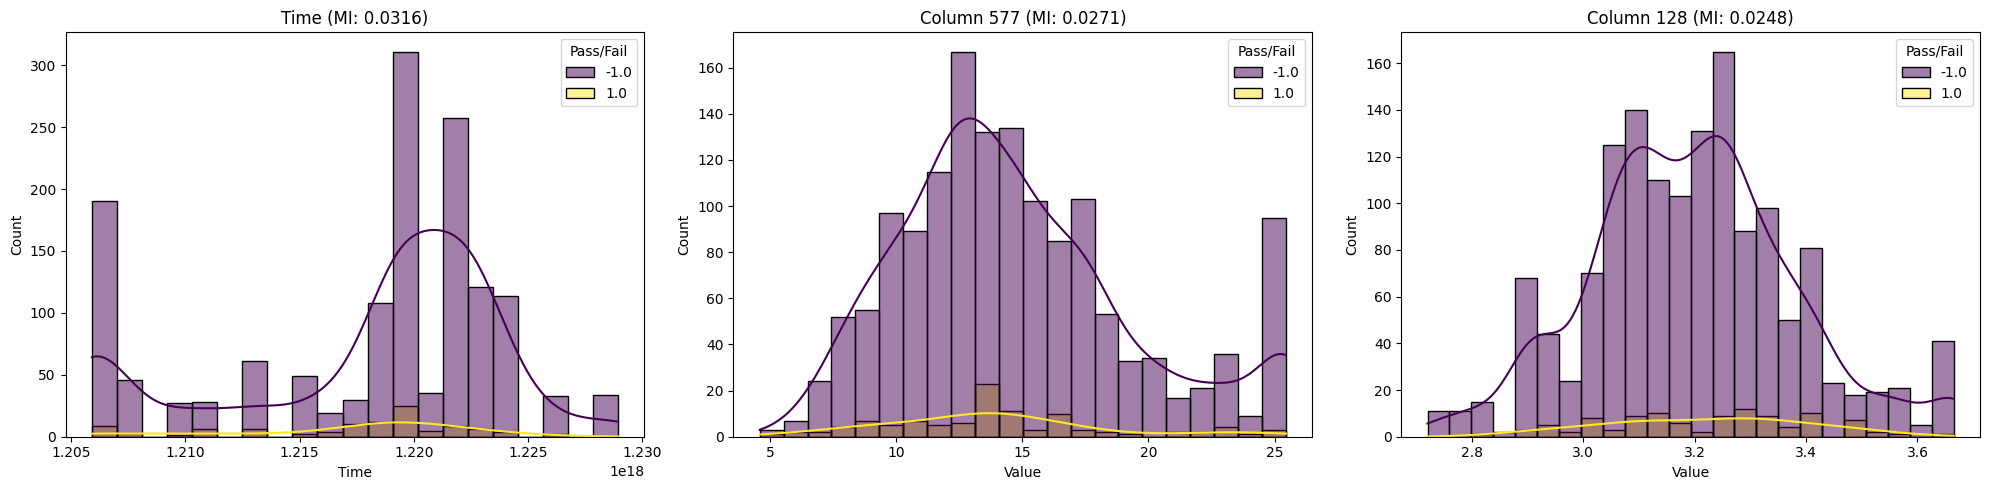

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Time - 시간 흐름에 따른 불량 분포
sns.histplot(data=X, x='Time', hue=y, kde=True, ax=axes[0], palette='viridis')
axes[0].set_title(f"Time (MI: {mi_df['Time']:.4f})")
axes[0].set_xlabel("Time")

# 577
sns.histplot(data=X, x='577', hue=y, kde=True, ax=axes[1], palette='viridis')
axes[1].set_title(f"Column 577 (MI: {mi_df['577']:.4f})")
axes[1].set_xlabel("Value")

# 128
sns.histplot(data=X, x='128', hue=y, kde=True, ax=axes[2], palette='viridis')
axes[2].set_title(f"Column 128 (MI: {mi_df['128']:.4f})")
axes[2].set_xlabel("Value")

plt.tight_layout()
plt.show()

In [44]:
# Pass와 Fail의 분포가 거의 겹침 -> 단변수로는 안 됨
# 모든 열을 전수 조사는 불가능 -> 피처 선택 필요 -> 과적합 방지, 해석력 확보, 계산 효율성 및 중복성 제거